# Pagan Lab — Optogenetics Data

This notebook demonstrates how to access optogenetics data from
**[DANDI:001550](https://dandiarchive.org/dandiset/001550)**.

The example session (TaskSwitch6, subject P131, 2019-08-15) used the **Cerebro wireless
optogenetics system** (Karpova Lab) to bilaterally inactivate the Frontal Orienting
Field (FOF) on most trials via AAV2/5-mDlx-ChR2-mCherry.

**Reference:** Pagan et al., *Nature* 639, 421–429 (2025).
doi:[10.1038/s41586-024-08433-6](https://doi.org/10.1038/s41586-024-08433-6)

## 1. Stream the NWB file from DANDI


In [15]:
import h5py
import numpy as np
import pandas as pd
import remfile
from dandi.dandiapi import DandiAPIClient
from matplotlib import pyplot as plt
from pynwb import NWBHDF5IO

DANDISET_ID = "001550"
ASSET_PATH  = "sub-P131/sub-P131_ses-TaskSwitch6-190815a.nwb"

with DandiAPIClient() as client:
    asset = client.get_dandiset(DANDISET_ID, "draft").get_asset_by_path(ASSET_PATH)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=False)

file_system = remfile.File(s3_url)
h5_file = h5py.File(file_system, "r")
io = NWBHDF5IO(file=h5_file)
nwbfile = io.read()

## 2. Session and subject metadata

In [16]:
print("Session ID:     ", nwb.session_id)
print("Session start:  ", nwb.session_start_time)
sub = nwb.subject
print("Subject ID:     ", sub.subject_id)
print("Species:        ", sub.species)
print("Strain:         ", sub.strain)
print("Sex:            ", sub.sex)
print("Date of birth:  ", sub.date_of_birth.date())

Session ID:      TaskSwitch6-190815a
Session start:   2019-08-15 11:41:00+01:00
Subject ID:      P131
Species:         Rattus norvegicus
Strain:          Long Evans
Sex:             M
Date of birth:   2017-06-27


## 3. Optogenetic stimulus sites

Two `OptogeneticStimulusSite` objects describe the implant locations — one per hemisphere.
The virus **AAV2/5-mDlx-ChR2-mCherry** was used to express ChR2 in interneurons;
stimulation wavelength is 473 nm. The Cerebro wireless system (Karpova Lab) delivered
the light.

In [17]:
for name, site in nwb.ogen_sites.items():
    print(f"--- {name} ---")
    print(f"  Location:          {site.location}")
    print(f"  Excitation lambda: {site.excitation_lambda} nm")
    print(f"  Device:            {site.device.name} ({site.device.manufacturer})")
    print(f"  Description:       {site.description}")

--- opto_site_left ---
  Location:          Frontal Orienting Field (FOF), left hemisphere
  Excitation lambda: 473.0 nm
  Device:            Cerebro_laser (Karpova Lab)
  Description:       Optical fiber in the left hemisphere FOF, +2 mm AP, -1.3 mm ML from bregma.
--- opto_site_right ---
  Location:          Frontal Orienting Field (FOF), right hemisphere
  Excitation lambda: 473.0 nm
  Device:            Cerebro_laser (Karpova Lab)
  Description:       Optical fiber in the right hemisphere FOF, +2 mm AP, +1.3 mm ML from bregma.


## 4. Structured optogenetics metadata (ndx-optogenetics)

Rich metadata is stored using the [ndx-optogenetics](https://github.com/rly/ndx-optogenetics)
NWB extension inside an `OptogeneticExperimentMetadata` object.

This provides queryable fields for:
- **Excitation source** — device model, power
- **Optical fiber** — NA, core diameter, per-hemisphere implant coordinates
- **Viral vector** — construct name, manufacturer
- **Virus injections** — stereotactic coordinates per hemisphere

In [18]:
opto_meta = nwb.lab_meta_data["optogenetic_experiment_metadata"]
print("Stimulation software:", opto_meta.stimulation_software)

# Excitation source device (ndx-optogenetics 0.3.x: ExcitationSource has power_in_W;
# wavelength lives on ExcitationSourceModel, or is recorded per-epoch in the epochs table)
cerebro = nwb.devices["Cerebro"]
print(f"\nExcitation source: {cerebro.name}  (manufacturer: {cerebro.manufacturer})")
print(f"  Power:      {cerebro.power_in_W * 1000:.0f} mW")

# Wavelength — stored per epoch in OptogeneticEpochsTable (ndx-optogenetics 0.3.x)
epochs_tbl = nwb.intervals["optogenetic_epochs"]
print(f"  Wavelength: {epochs_tbl['wavelength_in_nm'][0]:.0f} nm  (from epochs table)")

# OptogeneticSitesTable — one row per hemisphere implant (replaces OpticalFiberLocationsTable in 0.2.x)
sites_table = opto_meta.optogenetic_sites_table
print(f"\nOptogenetic sites ({len(sites_table.id)} implant locations):")
for i in range(len(sites_table.id)):
    fiber = sites_table["optical_fiber"][i]
    fi    = fiber.fiber_insertion
    print(
        f"  Site {i}: {fiber.description}\n"
        f"           AP={fi.insertion_position_ap_in_mm:+.1f} mm  "
        f"ML={fi.insertion_position_ml_in_mm:+.1f} mm"
    )

# Virus (ndx-ophys-devices 0.3.x: ViralVector stored under .viral_vectors)
virus = next(iter(opto_meta.optogenetic_viruses.viral_vectors.values()))
print(f"\nVirus construct: {virus.construct_name}")
print(f"  Manufacturer:  {virus.manufacturer}")

# Injections (ndx-ophys-devices 0.3.x: ViralVectorInjection under .viral_vector_injections)
print("\nVirus injections:")
for inj in opto_meta.optogenetic_virus_injections.viral_vector_injections.values():
    print(
        f"  {inj.hemisphere:6s}  "
        f"AP={inj.ap_in_mm:+.1f} mm  "
        f"ML={inj.ml_in_mm:+.1f} mm  "
        f"→ {inj.location}"
    )

Stimulation software: BControl / Cerebro

Excitation source: Cerebro  (manufacturer: Karpova Lab)
  Power:      25 mW
  Wavelength: 473 nm  (from epochs table)

Optogenetic sites (2 implant locations):
  Site 0: Optical fiber implanted in the left hemisphere FOF (+2 mm AP, -1.3 mm ML from bregma).
           AP=+2.0 mm  ML=-1.3 mm
  Site 1: Optical fiber implanted in the right hemisphere FOF (+2 mm AP, +1.3 mm ML from bregma).
           AP=+2.0 mm  ML=+1.3 mm

Virus construct: AAV2/5-mDlx-ChR2-mCherry
  Manufacturer:  unknown

Virus injections:
  left    AP=+2.0 mm  ML=-1.3 mm  → Frontal Orienting Field (FOF)
  right   AP=+2.0 mm  ML=+1.3 mm  → Frontal Orienting Field (FOF)


## 5. OptogeneticSeries — laser power over time

Two `OptogeneticSeries` are stored in `nwb.stimulus` — one per hemisphere.
Each uses a **step-function** encoding:
- Onset sample: **power = 0.025 W (25 mW)**
- Offset sample immediately after: **power = 0 W**

> **Power units:** watts (SI). The raw Cerebro internal threshold (≥ 800) was used
> during conversion to determine laser-on vs. laser-off; all values above threshold
> correspond to 25 mW.

In [19]:
opto_left  = nwb.stimulus["optogenetic_series_left"]
opto_right = nwb.stimulus["optogenetic_series_right"]

print(f"Unit: {opto_left.unit}")  # "watts"
print()
print("Left series:")
print(f"  n samples:  {len(opto_left.data)}")
print(f"  data[:8]:   {opto_left.data[:8]}")   # alternates 0.025 / 0.0
print(f"  timestamps: {opto_left.timestamps[:8]}")
print()
print("Right series:")
print(f"  n samples:  {len(opto_right.data)}")
print(f"  data[:8]:   {opto_right.data[:8]}")

Unit: watts

Left series:
  n samples:  1228
  data[:8]:   [0.    0.    0.025 0.    0.    0.    0.    0.   ]
  timestamps: [1449.866753 1451.166753 1457.688753 1458.338753 1468.262754 1468.912754
 1475.819754 1476.469754]

Right series:
  n samples:  1228
  data[:8]:   [0.    0.    0.025 0.    0.    0.    0.    0.   ]


## 6. Reconstruct stimulation intervals

Each consecutive on/off sample pair defines one stimulation interval.

In [20]:
def get_stim_intervals(series):
    """Return (on_times, off_times, powers) from a step-function OptogeneticSeries."""
    data = np.array(series.data[:])
    ts   = np.array(series.timestamps[:])
    on_mask = data > 0
    on_times  = ts[on_mask]
    off_times = ts[np.where(on_mask)[0] + 1]  # offset sample immediately follows
    powers    = data[on_mask]
    return on_times, off_times, powers

on_l, off_l, pwr_l = get_stim_intervals(opto_left)
on_r, off_r, pwr_r = get_stim_intervals(opto_right)

print(f"Left:  {len(on_l)} stimulation intervals")
print(f"Right: {len(on_r)} stimulation intervals")
print()
df_left = pd.DataFrame({"t_on": on_l[:5], "t_off": off_l[:5], "power": pwr_l[:5]})
print("First 5 left-hemisphere intervals:")
print(df_left.to_string(index=False))

Left:  137 stimulation intervals
Right: 128 stimulation intervals

First 5 left-hemisphere intervals:
       t_on       t_off  power
1457.688753 1458.338753  0.025
1516.250754 1517.550754  0.025
1541.370253 1542.020253  0.025
1580.621753 1581.271753  0.025
1606.274253 1606.924253  0.025


## 7. Visualise laser power

Step-function laser power for both hemispheres over the first 500 s of the session.

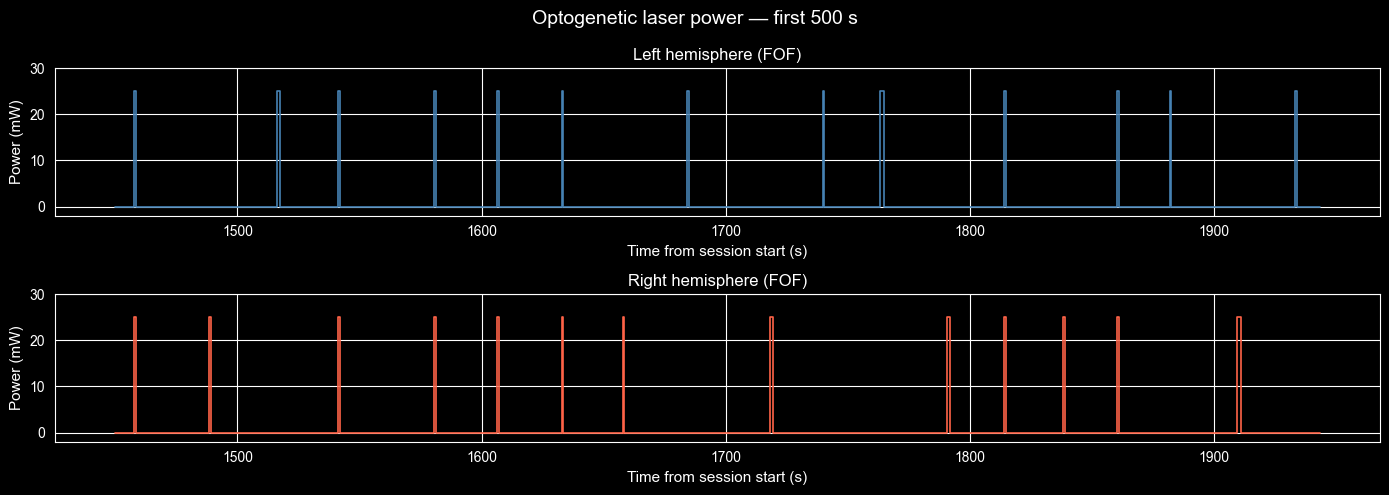

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=False)

for ax, series, label, color in zip(
    axes,
    [opto_left, opto_right],
    ["Left hemisphere (FOF)", "Right hemisphere (FOF)"],
    ["steelblue", "tomato"],
):
    data = np.array(series.data[:])
    ts   = np.array(series.timestamps[:])
    # Show first 500 s of the session
    mask = ts < ts[0] + 500
    ax.step(ts[mask], data[mask] * 1000, where="post", color=color, lw=1.2)  # convert W → mW
    ax.set_ylabel("Power (mW)", fontsize=11)
    ax.set_ylim(-2, 30)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Time from session start (s)", fontsize=11)

plt.suptitle("Optogenetic laser power — first 500 s", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Per-trial opto columns and stimulation epochs

### Trials table opto columns

Two columns in `nwbfile.trials` describe stimulation scheduling:

| Column | Content |
|---|---|
| `OptoSection_opto_connected` | 1 = Cerebro was connected on this trial; 0 = not connected |
| `OptoSection_opto_type` | Window label: `'Full Trial'` (0–1.3 s), `'First Half'` (0–0.65 s), or `'Second Half'` (0.65–1.3 s) relative to cpoke onset |

**Note:** Raw per-hemisphere power values are not stored as trial columns — the
hemisphere-resolved power is fully encoded in `optogenetic_series_left` /
`optogenetic_series_right`.

### OptogeneticEpochsTable

`nwb.intervals["optogenetic_epochs"]` contains one row per stimulation interval with
structured protocol fields: `stimulation_on`, `pulse_length_in_ms`, `power_in_mW`,
`wavelength_in_nm`, etc.

In [22]:
epochs = nwb.intervals["optogenetic_epochs"]
n_epochs = len(epochs.id)
print(f"Total stimulation epochs: {n_epochs}")

# Build a DataFrame from individual columns (avoids an hdmf compat issue with to_dataframe())
import pandas as pd

epochs_df = pd.DataFrame({
    "start_time":          epochs["start_time"][:],
    "stop_time":           epochs["stop_time"][:],
    "stimulation_on":      epochs["stimulation_on"][:],
    "pulse_length_in_ms":  epochs["pulse_length_in_ms"][:],
    "power_in_mW":         epochs["power_in_mW"][:],
})

print("\nWindow-type distribution (by pulse_length_in_ms):")
print(epochs_df["pulse_length_in_ms"].value_counts().rename({1300.0: "Full Trial (1300 ms)", 650.0: "Half Trial (650 ms)"}).to_string())
print()
epochs_df.head(10)

Total stimulation epochs: 614

Window-type distribution (by pulse_length_in_ms):
pulse_length_in_ms
Half Trial (650 ms)     424
Full Trial (1300 ms)    190



,start_time,stop_time,stimulation_on,pulse_length_in_ms,power_in_mW
0,1449.866753,1451.166753,True,1300.0,25.0
1,1457.688753,1458.338753,True,650.0,25.0
2,1468.262754,1468.912754,True,650.0,25.0
3,1475.819754,1476.469754,True,650.0,25.0
4,1488.349256,1488.999256,True,650.0,25.0
5,1499.350754,1500.000754,True,650.0,25.0
6,1507.201258,1507.851258,True,650.0,25.0
7,1516.250754,1517.550754,True,1300.0,25.0
8,1523.471254,1524.771254,True,1300.0,25.0
9,1531.310753,1532.610753,True,1300.0,25.0
